# 2개 피처로 배터리 수명 예측하기 — Ridge 셀 따라가기

**목표:** 처음 100사이클까지 얻은 정보로 배터리의 총 `cycle_life`를 예측합니다.
한 행은 배터리 셀 하나이고, 입력은 보고서에서 선정한 **두 피처만** 사용합니다.

| 역할 | 컬럼 | 의미 |
|---|---|---|
| 입력 1 | `log10_delta_q_var` | 방전곡선 변화량 ΔQ의 분산에 log10 적용 |
| 입력 2 | `SOC_switch_pct` | 충전 전류를 전환하는 SOC (%) |
| 정답 | `cycle_life` | 배터리의 총수명 (cycle) |

피처 선정 근거: [Notion 2피처 보고서](https://app.notion.com/p/3ecd54b5a6d7818f99bde98f1cef9db1).
첨부한 `ML_2)_Regression.ipynb`처럼 **데이터 준비 → 확인 → 분할 → 결측 처리 → 표준화 → 모델 정의 → 학습 → 예측 → 평가** 순서로 구성했습니다.
코드 셀을 위에서 아래로 하나씩 실행하며 바로 아래의 출력으로 결과를 확인하세요.

## 1. 준비

최종 모델은 Ridge 하나이며, 정답에 로그를 적용하지 않고 **원래 사이클 단위로 학습**합니다.
먼저 `alpha=1`로 학습 과정을 익힌 뒤, Batch 1 개발 데이터의 CV로 최종 `alpha`를 선택합니다.

평가 순서: **Batch 1 개발 데이터에서 설정 선택 → Batch 1 hold-out 확인 → Batch 1 전체로 재학습 → Batch 2 평가**.
충전 정책은 데이터 분할용 그룹이고 모델의 입력 피처가 아닙니다.

In [45]:
from pathlib import Path
import hashlib
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

FEATURES = ["log10_delta_q_var", "SOC_switch_pct"]
TARGET = "cycle_life"
SEED = 20261002
ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]
PAPER_TARGET_MAPE = 9.1  # 과제에서 제시한 참고 목표 (%)
pd.set_option("display.max_columns", 20)

프로젝트 폴더나 `Modeling` 폴더 어느 곳에서 실행해도 같은 입력 파일을 찾습니다.
CSV는 기존 EDA 결과를 읽고, 이 실습의 결과는 `Modeling/results/ridge_step_by_step`에 저장합니다.

In [46]:
ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / "data").is_dir() and (p / "results" / "five_questions").is_dir()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("archive 프로젝트 또는 그 하위 폴더에서 실행하세요.")

SOURCE = ROOT / "results" / "five_questions"
OUT = ROOT / "Modeling" / "results" / "ridge_step_by_step"
OUT.mkdir(parents=True, exist_ok=True)
print("입력:", SOURCE)
print("결과:", OUT)

입력: /Users/suyeong/Downloads/archive/results/five_questions
결과: /Users/suyeong/Downloads/archive/Modeling/results/ridge_step_by_step


## 2. 데이터 준비

`log10_delta_q_var = log10(Var(Q100(V) − Q10(V)))`입니다. `Q10`, `Q100`은 실제 10, 100사이클의
전압별 방전용량 곡선입니다. 따라서 이 모델의 예측 시점은 **100사이클 관측 후**입니다.
`SOC_switch_pct=80`이면 SOC 80%에서 충전 전류를 전환하는 정책을 뜻합니다.

세 CSV에서 필요한 컬럼을 직접 읽습니다. 셀 식별자 `cell_uid`로 합치고,
각 파일의 수명 라벨이 같은지도 확인합니다.

In [47]:
metadata = pd.read_csv(
    SOURCE / "cell_metadata.csv",
    usecols=["cell_uid", "batch_id", "cycle_life", "charging_policy"],
)
delta = pd.read_csv(
    SOURCE / "delta_q_features.csv",
    usecols=["cell_uid", "batch_id", "cycle_life", "log10_delta_q_var", "dq_status"],
)
current = pd.read_csv(
    SOURCE / "current_features.csv",
    usecols=["cell_uid", "batch_id", "cycle_life", "charging_policy",
             "SOC_switch_pct", "C1", "C2", "policy_suffix"],
)
display(metadata.head(), delta.head(), current.head())

,batch_id,cell_uid,cycle_life,charging_policy
0,B1,B1_0,1190.0,3.6C(80%)-3.6C
1,B1,B1_1,1179.0,3.6C(80%)-3.6C
2,B1,B1_2,1177.0,3.6C(80%)-3.6C
3,B1,B1_3,1226.0,4C(80%)-4C
4,B1,B1_4,1227.0,4C(80%)-4C


,cell_uid,batch_id,log10_delta_q_var,dq_status,cycle_life
0,B1_0,B1,-5.014861,ok,1190.0
1,B1_1,B1,-5.013960,ok,1179.0
2,B1_2,B1,-4.737000,ok,1177.0
3,B1_3,B1,-4.442613,ok,1226.0
4,B1_4,B1,-4.647744,ok,1227.0


,cell_uid,batch_id,charging_policy,C1,SOC_switch_pct,C2,policy_suffix,cycle_life
0,B1_0,B1,3.6C(80%)-3.6C,3.6,80.0,3.6,NaN,1190.0
1,B1_1,B1,3.6C(80%)-3.6C,3.6,80.0,3.6,NaN,1179.0
2,B1_2,B1,3.6C(80%)-3.6C,3.6,80.0,3.6,NaN,1177.0
3,B1_3,B1,4C(80%)-4C,4.0,80.0,4.0,NaN,1226.0
4,B1_4,B1,4C(80%)-4C,4.0,80.0,4.0,NaN,1227.0


In [48]:
# 같은 셀의 기록이 중복되거나 누락된 상태에서 합쳐지는 것을 막습니다.
for name, frame in [("metadata", metadata), ("delta", delta), ("current", current)]:
    assert frame["cell_uid"].notna().all(), f"{name}: 셀 식별자 누락"
    assert frame["cell_uid"].is_unique, f"{name}: 중복 셀"
    assert set(frame["cell_uid"]) == set(metadata["cell_uid"]), f"{name}: 셀 목록 불일치"

data = metadata.merge(
    delta.rename(columns={"batch_id": "batch_delta", "cycle_life": "life_delta"}),
    on="cell_uid", how="left", validate="one_to_one",
).merge(
    current.rename(columns={"batch_id": "batch_current", "cycle_life": "life_current",
                            "charging_policy": "policy_current"}),
    on="cell_uid", how="left", validate="one_to_one",
)
for label_column in ["life_delta", "life_current"]:
    assert np.isclose(data[TARGET], data[label_column], equal_nan=True).all(), "수명 라벨 불일치"
assert data["batch_id"].eq(data["batch_delta"]).all()
assert data["batch_id"].eq(data["batch_current"]).all()
assert data["charging_policy"].eq(data["policy_current"]).all()
data = data.drop(columns=["batch_delta", "batch_current", "life_delta", "life_current", "policy_current"])
print("병합 후:", data.shape)

병합 후: (139, 10)


### 컬럼 정보와 결측값 확인

`info()`에서 행 수, 숫자/문자 자료형, 결측 여부를 확인합니다.
수명 라벨이 없거나 0 이하인 셀과 유효한 ΔQ 피처가 없는 셀은 제외합니다.
**정답 `y`는 대체하지 않습니다.** 입력의 무한대는 결측값으로 바꾸며 SOC 결측은 학습 데이터의 중앙값으로 처리합니다.

In [49]:
data.info()
display(data[FEATURES + [TARGET]].isna().sum().rename("missing_count").to_frame())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   batch_id           139 non-null    object 
 1   cell_uid           139 non-null    object 
 2   cycle_life         129 non-null    float64
 3   charging_policy    139 non-null    object 
 4   log10_delta_q_var  139 non-null    float64
 5   dq_status          139 non-null    object 
 6   C1                 135 non-null    float64
 7   SOC_switch_pct     135 non-null    float64
 8   C2                 135 non-null    float64
 9   policy_suffix      59 non-null     object 
dtypes: float64(5), object(5)
memory usage: 11.0+ KB


,missing_count
log10_delta_q_var,0
SOC_switch_pct,4
cycle_life,10


In [50]:
for column in FEATURES + [TARGET, "C1", "C2"]:
    data[column] = pd.to_numeric(data[column], errors="coerce").replace([np.inf, -np.inf], np.nan)

invalid_y = data[TARGET].isna() | data[TARGET].le(0)
invalid_delta = data["log10_delta_q_var"].isna() | data["dq_status"].fillna("").ne("ok")
data["eligible"] = ~(invalid_y | invalid_delta)
data["exclusion_reason"] = [
    "; ".join(reason for condition, reason in [
        (bad_y, "invalid_or_nonpositive_target"), (bad_delta, "invalid_delta_q")
    ] if condition)
    for bad_y, bad_delta in zip(invalid_y, invalid_delta)
]
excluded_cells = data.loc[~data["eligible"]].copy()
cohort_audit = data.groupby("batch_id").agg(
    raw_cells=("cell_uid", "size"), eligible_cells=("eligible", "sum")
).reset_index()
cohort_audit["excluded_cells"] = cohort_audit["raw_cells"] - cohort_audit["eligible_cells"]
data = data.loc[data["eligible"]].drop(columns=["eligible", "exclusion_reason"]).reset_index(drop=True)
display(cohort_audit, excluded_cells[["cell_uid", "exclusion_reason"]])

,batch_id,raw_cells,eligible_cells,excluded_cells
0,B1,46,46,0
1,B2,47,39,8
2,B3,46,44,2


,cell_uid,exclusion_reason
68,B2_22,invalid_or_nonpositive_target
69,B2_23,invalid_or_nonpositive_target
81,B2_35,invalid_or_nonpositive_target
82,B2_36,invalid_or_nonpositive_target
83,B2_37,invalid_or_nonpositive_target
84,B2_38,invalid_or_nonpositive_target
85,B2_39,invalid_or_nonpositive_target
86,B2_40,invalid_or_nonpositive_target
116,B3_23,invalid_or_nonpositive_target
125,B3_32,invalid_or_nonpositive_target


### 충전 정책을 그룹으로 묶기

같은 충전 정책을 사용한 셀은 비슷한 조건을 공유합니다. 이런 셀을 학습과 검증에 나눠 넣지 않도록
`C1 + 전환 SOC + C2 + 정책 접미사`를 정규화한 `policy_group`으로 묶습니다.
이 컬럼은 **분할에만** 사용합니다. 입력 `X`에는 두 피처만 들어갑니다.

In [51]:
suffix = data["policy_suffix"].fillna("none").astype(str).str.lower().str.replace(
    r"[^a-z0-9]", "", regex=True
).replace("", "none")
raw_policy = data["charging_policy"].fillna("").astype(str).str.lower().str.replace(
    r"\s+", "", regex=True
)
assert raw_policy.ne("").all(), "충전 정책 누락: 그룹 분할을 확인하세요."
data["policy_group"] = [
    f"C1={c1:g}|SOC={soc:g}|C2={c2:g}|suffix={tail}"
    if np.isfinite([c1, soc, c2]).all() else f"raw={raw}"
    for c1, soc, c2, tail, raw in zip(data["C1"], data["SOC_switch_pct"], data["C2"], suffix, raw_policy)
]
display(data.groupby("batch_id").agg(cells=("cell_uid", "size"), policies=("policy_group", "nunique")))

,cells,policies
batch_id,,
B1,46,23
B2,39,12
B3,44,8


### 짧은 EDA: 분포와 결측값

기존 EDA에서 피처 선택을 마쳤으므로 여기서는 Batch 1의 학습 준비 상태만 확인합니다.
`SOC_switch_pct`는 0~100의 백분율이고, 로그 분산 피처는 음수여도 정상입니다.
Batch 3은 이번 학습과 성능 평가에 사용하지 않습니다.

,log10_delta_q_var,SOC_switch_pct,cycle_life
count,46.000000,46.000000,46.000000
mean,-3.923430,51.521739,844.717391
std,0.378273,19.461345,184.629198
min,-5.014861,15.000000,534.000000
25%,-4.053411,40.000000,703.250000
50%,-3.851160,50.000000,858.500000
75%,-3.668210,67.500000,914.250000
max,-3.350338,80.000000,1227.000000


,missing_count
log10_delta_q_var,0
SOC_switch_pct,0
cycle_life,0


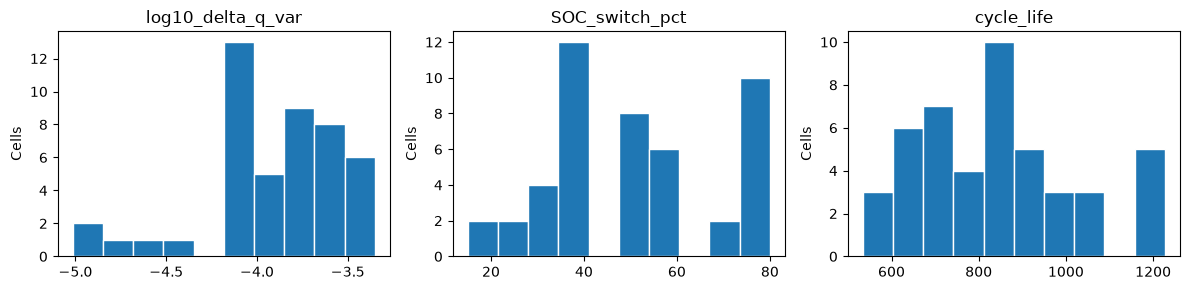

In [52]:
batch1 = data.loc[data["batch_id"].eq("B1")].copy().reset_index(drop=True)
batch2 = data.loc[data["batch_id"].eq("B2")].copy().reset_index(drop=True)
assert len(batch1) == 46 and len(batch2) == 39, "기존 EDA 코호트와 셀 수가 다릅니다."
assert batch1["policy_group"].nunique() == 23
display(batch1[FEATURES + [TARGET]].describe())
display(batch1[FEATURES + [TARGET]].isna().sum().rename("missing_count").to_frame())

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, column in zip(axes, FEATURES + [TARGET]):
    ax.hist(batch1[column].dropna(), bins=10, edgecolor="white")
    ax.set_title(column)
    ax.set_ylabel("Cells")
fig.tight_layout()
plt.show()

## 3. X, y 분리와 데이터 분할

`X`는 입력 두 열, `y`는 총수명 한 열입니다. `groups`는 같은 정책의 셀을 함께 분할하기 위한 정보입니다.

In [53]:
X = batch1[FEATURES].copy()
y = batch1[TARGET].copy()
groups = batch1["policy_group"].copy()
assert list(X.columns) == FEATURES
print("X:", X.shape, " / y:", y.shape)
display(X.head(), y.head().rename("target_cycle_life"))

X: (46, 2)  / y: (46,)


,log10_delta_q_var,SOC_switch_pct
0,-5.014861,80.0
1,-5.013960,80.0
2,-4.737000,80.0
3,-4.442613,80.0
4,-4.647744,80.0


0    1190.0
1    1179.0
2    1177.0
3    1226.0
4    1227.0
Name: target_cycle_life, dtype: float64

### Batch 1의 약 20% 정책을 hold-out으로 고정

`GroupShuffleSplit`의 `test_size=0.2`는 **정책 그룹의 20%**를 뜻합니다.
현재 데이터에서는 개발용 36셀(18정책), hold-out 10셀(5정책)입니다.
`X_train`은 설정을 선택하고 학습할 개발 데이터, `X_valid`는 설정 선택 후 평가할 hold-out입니다.
Batch 2는 별도 외부 평가 데이터입니다.

In [54]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, valid_idx = next(splitter.split(X, y, groups))
X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[valid_idx].copy()
y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[valid_idx].copy()
groups_train, groups_valid = groups.iloc[train_idx].copy(), groups.iloc[valid_idx].copy()

assert set(groups_train).isdisjoint(set(groups_valid)), "정책 그룹이 겹칩니다."
assert set(train_idx).isdisjoint(set(valid_idx)), "셀 식별자가 겹칩니다."
assert len(X_train) == 36 and len(X_valid) == 10
split_summary = pd.DataFrame([
    {"split": "B1 development", "cells": len(X_train), "policy_groups": groups_train.nunique()},
    {"split": "B1 hold-out", "cells": len(X_valid), "policy_groups": groups_valid.nunique()},
    {"split": "B2 external evaluation", "cells": len(batch2), "policy_groups": batch2["policy_group"].nunique()},
])
display(split_summary)

,split,cells,policy_groups
0,B1 development,36,18
1,B1 hold-out,10,5
2,B2 external evaluation,39,12


## 4. Feature Transformation — 직접 따라 하기

### Missing 처리: 학습 데이터의 중앙값

첨부 실습의 중앙값 대체와 같은 원리입니다. `fit_transform(X_train)`은 학습 데이터에서 중앙값을 계산하고 적용합니다.
검증 데이터에서는 새로운 중앙값을 계산하지 않고 `transform`만 사용합니다.
이 절에서는 학습 과정 이해를 위해 `alpha=1` 모델을 연습합니다.

In [55]:
imputer_demo = SimpleImputer(strategy="median").set_output(transform="pandas")
X_train_imputed_demo = imputer_demo.fit_transform(X_train)
display(pd.Series(imputer_demo.statistics_, index=FEATURES, name="Train median"))
display(X_train_imputed_demo.head())

log10_delta_q_var    -3.985677
SOC_switch_pct       50.000000
Name: Train median, dtype: float64

,log10_delta_q_var,SOC_switch_pct
0,-5.014861,80.0
1,-5.013960,80.0
2,-4.737000,80.0
3,-4.442613,80.0
4,-4.647744,80.0


### Scaling: StandardScaler

Ridge는 계수 크기에 벌점을 주므로 두 입력의 단위를 맞춥니다.
각 피처를 `z = (값 − 학습 평균) / 학습 표준편차`로 바꿉니다.
원래 로그 분산과 SOC(%)는 단위와 범위가 달라 표준화가 필요합니다.

In [56]:
scaler_demo = StandardScaler().set_output(transform="pandas")
X_train_scaled_demo = scaler_demo.fit_transform(X_train_imputed_demo)
display(pd.DataFrame({"mean": scaler_demo.mean_, "scale": scaler_demo.scale_}, index=FEATURES))
display(X_train_scaled_demo.head())

,mean,scale
log10_delta_q_var,-3.962681,0.409110
SOC_switch_pct,53.611111,20.602424


,log10_delta_q_var,SOC_switch_pct
0,-2.571874,1.280863
1,-2.569671,1.280863
2,-1.892690,1.280863
3,-1.173112,1.280863
4,-1.674518,1.280863


## 5. Ridge 모델 정의 → 학습 → 예측

Ridge의 예측식은 `수명 = intercept + w1 × z1 + w2 × z2`입니다.
학습에서는 **예측 오차의 제곱합 + alpha × 계수 제곱합**을 줄입니다.
`alpha`가 클수록 큰 계수를 더 강하게 제한하고, 절편(intercept)은 이 벌점에서 제외합니다.

먼저 모델 객체를 정의합니다. 아직 학습은 하지 않은 상태입니다.

In [57]:
ridge_demo = Ridge(alpha=1.0)
ridge_demo

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

### fit: 두 피처와 실제 수명의 관계 학습

`fit` 후 `coef_`에 두 계수, `intercept_`에 절편이 저장됩니다.

In [58]:
ridge_demo.fit(X_train_scaled_demo, y_train)
print("절편:", round(ridge_demo.intercept_, 3))
display(pd.Series(ridge_demo.coef_, index=FEATURES, name="standardized_coefficient"))

절편: 855.972


log10_delta_q_var   -174.413919
SOC_switch_pct        -9.016412
Name: standardized_coefficient, dtype: float64

### predict와 평가 지표

우선 학습한 데이터의 예측값을 확인합니다. 아래 **Train-fit 오차는 학습 과정을 확인하는 값**입니다.
과제의 `Train (Batch 1 CV)`에는 이후 CV의 검증 폴드 오차를 기록합니다.

MAPE는 `평균(|실제 − 예측| / 실제) × 100`입니다. 예를 들어 10%이면 실제 수명 대비 절대 오차가 평균 10%입니다.
MAE/RMSE는 사이클 단위이고, R²는 실제 수명 변동을 얼마나 설명하는지 나타냅니다.

In [59]:
def calculate_metrics(actual, predicted):
    return {
        "MAPE_percent": mean_absolute_percentage_error(actual, predicted) * 100,
        "MAE_cycles": mean_absolute_error(actual, predicted),
        "RMSE_cycles": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted),
    }

train_pred_demo = ridge_demo.predict(X_train_scaled_demo)
display(pd.DataFrame({"actual": y_train, "predicted": train_pred_demo}).head())
display(pd.DataFrame([calculate_metrics(y_train, train_pred_demo)], index=["Train-fit / alpha=1 demo"]))

,actual,predicted
0,1190.0,1292.994065
1,1179.0,1292.609765
2,1177.0,1174.534834
3,1226.0,1049.030546
4,1227.0,1136.482731


,MAPE_percent,MAE_cycles,RMSE_cycles,R2
Train-fit / alpha=1 demo,8.254813,70.885432,88.361976,0.799145


## 6. alpha 비교 — 개발 데이터의 그룹 CV

36셀을 정책별 3개 폴드로 나누고, 각 `alpha`마다 **학습 2개 폴드 → 나머지 1개 폴드 평가**를 반복합니다.
중앙값과 표준화 기준도 매번 그 폴드의 학습 데이터에서 계산해야 합니다.

이 반복에서는 `Pipeline`으로 **중앙값 대체 → 표준화 → Ridge**를 연결합니다.
앞에서 직접 실행한 세 단계를 그대로 묶는 것이며, `fit`과 `predict`는 아래 반복문에 보입니다.

In [60]:
def make_ridge_pipeline(alpha):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median").set_output(transform="pandas")),
        ("scaler", StandardScaler().set_output(transform="pandas")),
        ("ridge", Ridge(alpha=float(alpha))),
    ])

cv = GroupKFold(n_splits=3)
cv_splits = list(cv.split(X_train, y_train, groups_train))
for fold_train_idx, fold_valid_idx in cv_splits:
    assert set(groups_train.iloc[fold_train_idx]).isdisjoint(set(groups_train.iloc[fold_valid_idx]))
print("개발 데이터 CV 폴드 수:", len(cv_splits))

개발 데이터 CV 폴드 수: 3


In [61]:
alpha_trials = []
for alpha in ALPHAS:
    for fold, (fold_train_idx, fold_valid_idx) in enumerate(cv_splits, start=1):
        X_fold_train = X_train.iloc[fold_train_idx]
        y_fold_train = y_train.iloc[fold_train_idx]
        X_fold_valid = X_train.iloc[fold_valid_idx]
        y_fold_valid = y_train.iloc[fold_valid_idx]

        # 폴드마다 새 전처리 객체와 모델을 만듭니다.
        fold_model = make_ridge_pipeline(alpha)
        fold_model.fit(X_fold_train, y_fold_train)
        fold_pred = fold_model.predict(X_fold_valid)
        alpha_trials.append({"alpha": alpha, "fold": fold,
                             "train_cells": len(X_fold_train), "valid_cells": len(X_fold_valid),
                             **calculate_metrics(y_fold_valid, fold_pred)})

alpha_trials = pd.DataFrame(alpha_trials)
display(alpha_trials)

,alpha,fold,train_cells,valid_cells,MAPE_percent,MAE_cycles,RMSE_cycles,R2
0,0.01,1,24,12,8.983726,88.625410,112.182204,0.752591
1,0.01,2,24,12,9.175367,88.053862,106.339995,0.717321
2,0.01,3,24,12,10.087557,75.504571,90.983316,0.517989
3,0.10,1,24,12,8.940830,88.133486,111.432345,0.755887
4,0.10,2,24,12,9.211243,88.359265,106.522551,0.716350
5,0.10,3,24,12,10.112024,75.629602,91.122354,0.516515
6,1.00,1,24,12,8.532146,83.440195,104.653105,0.784686
7,1.00,2,24,12,9.551944,91.253912,108.423003,0.706138
8,1.00,3,24,12,10.350015,76.856796,92.572257,0.501006
9,10.00,1,24,12,9.049486,73.033772,86.025370,0.854514


,alpha,CV_MAPE_mean,CV_MAPE_std,CV_RMSE_mean
0,0.01,9.415550,0.589810,103.168505
1,0.10,9.421366,0.613219,103.025750
2,1.00,9.478035,0.911186,101.882788
3,10.00,11.020892,1.718372,106.802010
4,100.00,17.545113,0.911535,170.855399


개발 데이터에서 선택한 최종 alpha: 0.01


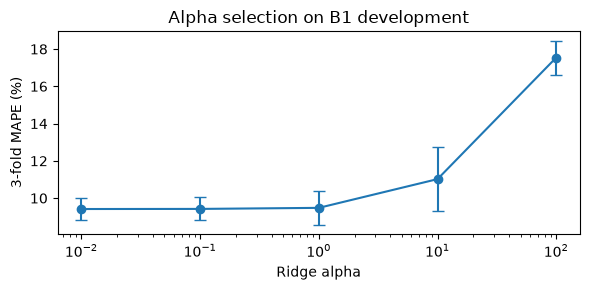

In [62]:
alpha_scores = alpha_trials.groupby("alpha", as_index=False).agg(
    CV_MAPE_mean=("MAPE_percent", "mean"), CV_MAPE_std=("MAPE_percent", "std"),
    CV_RMSE_mean=("RMSE_cycles", "mean"),
).sort_values(["CV_MAPE_mean", "alpha"]).reset_index(drop=True)
best_alpha = float(alpha_scores.iloc[0]["alpha"])
display(alpha_scores)
print("개발 데이터에서 선택한 최종 alpha:", best_alpha)

fig, ax = plt.subplots(figsize=(6, 3))
plot_scores = alpha_scores.sort_values("alpha")
ax.errorbar(plot_scores["alpha"], plot_scores["CV_MAPE_mean"],
            yerr=plot_scores["CV_MAPE_std"], fmt="o-", capsize=4)
ax.set(xscale="log", xlabel="Ridge alpha", ylabel="3-fold MAPE (%)", title="Alpha selection on B1 development")
fig.tight_layout()
fig.savefig(OUT / "alpha_comparison.png", dpi=150)
plt.show()

### 제출용 Train CV: 설정 선택과 평가를 한 번 더 분리

위 3-fold 점수는 가장 좋은 `alpha`를 **선택한 기준**입니다. 같은 점수를 최종 성능으로 쓰면 낙관적일 수 있습니다.
제출용 CV는 개발 데이터에 **5-fold 바깥 평가 + 각 바깥 학습 데이터 안의 3-fold alpha 선택**을 적용합니다.
이를 nested CV라고 합니다.

| 반복 | 사용 데이터 | 역할 |
|---|---|---|
| 안쪽 3-fold | 바깥 학습 데이터 | alpha 선택 |
| 바깥 5-fold | 안쪽에서 사용하지 않은 바깥 검증 데이터 | 성능 평가 |

바깥 폴드마다 `alpha`가 달라도 정상입니다. 최종 모델의 `best_alpha`는 앞에서 **개발 데이터 전체**로 선택한 값을 유지합니다.
hold-out과 Batch 2는 이 과정에서 사용하지 않습니다.

In [63]:
outer_cv = GroupKFold(n_splits=5)
outer_splits = list(outer_cv.split(X_train, y_train, groups_train))
nested_trials = []
nested_fold_scores = []
cv_oof_pred = pd.Series(index=X_train.index, dtype=float, name="predicted")
print("바깥 평가 폴드:", len(outer_splits), "/ 각 바깥 학습 데이터의 안쪽 폴드: 3")

바깥 평가 폴드: 5 / 각 바깥 학습 데이터의 안쪽 폴드: 3


In [64]:
for outer_fold, (outer_train_idx, outer_valid_idx) in enumerate(outer_splits, start=1):
    X_outer_train, y_outer_train = X_train.iloc[outer_train_idx], y_train.iloc[outer_train_idx]
    X_outer_valid, y_outer_valid = X_train.iloc[outer_valid_idx], y_train.iloc[outer_valid_idx]
    groups_outer_train = groups_train.iloc[outer_train_idx]
    assert set(groups_outer_train).isdisjoint(set(groups_train.iloc[outer_valid_idx]))
    inner_splits = list(GroupKFold(n_splits=3).split(X_outer_train, y_outer_train, groups_outer_train))

    # 1) 안쪽 CV: 바깥 학습 데이터만 사용하여 alpha 선택
    outer_alpha_scores = []
    for alpha in ALPHAS:
        inner_mapes = []
        for inner_fold, (inner_train_idx, inner_valid_idx) in enumerate(inner_splits, start=1):
            assert set(groups_outer_train.iloc[inner_train_idx]).isdisjoint(
                set(groups_outer_train.iloc[inner_valid_idx]))
            inner_model = make_ridge_pipeline(alpha)
            inner_model.fit(X_outer_train.iloc[inner_train_idx], y_outer_train.iloc[inner_train_idx])
            inner_pred = inner_model.predict(X_outer_train.iloc[inner_valid_idx])
            inner_mape = calculate_metrics(y_outer_train.iloc[inner_valid_idx], inner_pred)["MAPE_percent"]
            inner_mapes.append(inner_mape)
            nested_trials.append({"outer_fold": outer_fold, "alpha": alpha,
                                  "inner_fold": inner_fold, "MAPE_percent": inner_mape})
        outer_alpha_scores.append((float(np.mean(inner_mapes)), float(alpha)))
    _, outer_alpha = min(outer_alpha_scores)  # 동점이면 작은 alpha 선택

    # 2) 바깥 평가: 선택한 alpha로 바깥 학습 데이터를 재학습한 뒤 한 번 예측
    outer_model = make_ridge_pipeline(outer_alpha)
    outer_model.fit(X_outer_train, y_outer_train)
    outer_pred = outer_model.predict(X_outer_valid)
    cv_oof_pred.loc[X_outer_valid.index] = outer_pred
    nested_fold_scores.append({"outer_fold": outer_fold, "selected_alpha": outer_alpha,
                               "train_cells": len(X_outer_train), "valid_cells": len(X_outer_valid),
                               **calculate_metrics(y_outer_valid, outer_pred)})

nested_trials = pd.DataFrame(nested_trials)
nested_fold_scores = pd.DataFrame(nested_fold_scores)
assert cv_oof_pred.notna().all(), "모든 개발 셀은 바깥 CV에서 한 번씩 평가되어야 합니다."

In [65]:
cv_mape_mean = float(nested_fold_scores["MAPE_percent"].mean())
cv_mape_std = float(nested_fold_scores["MAPE_percent"].std())
cv_oof_predictions = batch1.loc[X_train.index, ["cell_uid", "policy_group", TARGET]].copy()
cv_oof_predictions["predicted"] = cv_oof_pred
cv_oof_predictions["APE_percent"] = (
    (cv_oof_predictions[TARGET] - cv_oof_predictions["predicted"]).abs() / cv_oof_predictions[TARGET] * 100
)
display(nested_fold_scores)
print(f"제출용 Train CV MAPE: {cv_mape_mean:.2f}% (폴드 표준편차 {cv_mape_std:.2f}%p)")
print("최종 모델 alpha:", best_alpha)

,outer_fold,selected_alpha,train_cells,valid_cells,MAPE_percent,MAE_cycles,RMSE_cycles,R2
0,1,1.00,29,7,10.216271,109.765116,135.737859,0.498548
1,2,0.01,28,8,12.064105,101.040205,116.547797,0.759388
2,3,0.01,28,8,9.404786,71.552677,80.986060,0.401915
3,4,0.01,29,7,11.236980,108.832727,123.995958,-0.589432
4,5,0.01,30,6,5.981450,36.118600,41.900637,0.924128


제출용 Train CV MAPE: 9.78% (폴드 표준편차 2.35%p)
최종 모델 alpha: 0.01


## 7. 선택한 alpha로 개발 데이터 학습

이제 `best_alpha`를 고정합니다. 중앙값 계산, 표준화, Ridge 학습을 다시 각각 실행합니다.
앞의 `alpha=1` 연습 모델 대신 이 모델을 hold-out 평가에 사용합니다.

In [66]:
imputer = SimpleImputer(strategy="median").set_output(transform="pandas")
X_train_imputed = imputer.fit_transform(X_train)
display(pd.Series(imputer.statistics_, index=FEATURES, name="Selected-model train median"))

log10_delta_q_var    -3.985677
SOC_switch_pct       50.000000
Name: Selected-model train median, dtype: float64

In [67]:
scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train_imputed)
display(X_train_scaled.head())

,log10_delta_q_var,SOC_switch_pct
0,-2.571874,1.280863
1,-2.569671,1.280863
2,-1.892690,1.280863
3,-1.173112,1.280863
4,-1.674518,1.280863


In [68]:
ridge = Ridge(alpha=best_alpha)
ridge.fit(X_train_scaled, y_train)
print("학습한 개발 셀 수:", len(y_train), "/ alpha:", ridge.alpha)
display(pd.Series(ridge.coef_, index=FEATURES, name="standardized_coefficient"))

학습한 개발 셀 수: 36 / alpha: 0.01


log10_delta_q_var   -180.022763
SOC_switch_pct       -11.280400
Name: standardized_coefficient, dtype: float64

## 8. Batch 1 hold-out 예측과 평가

검증 데이터에는 학습한 `imputer`, `scaler`의 **transform만** 적용합니다.
실제값과 예측값이 대각선에 가까울수록 좋습니다. 평가 후 hold-out 점수로 alpha를 바꾸지 않습니다.

In [69]:
X_valid_imputed = imputer.transform(X_valid)
X_valid_scaled = scaler.transform(X_valid_imputed)
valid_pred = ridge.predict(X_valid_scaled)
valid_metrics = calculate_metrics(y_valid, valid_pred)
holdout_predictions = batch1.loc[X_valid.index, ["cell_uid", "policy_group", TARGET]].copy()
holdout_predictions["predicted"] = valid_pred
holdout_predictions["APE_percent"] = (y_valid - valid_pred).abs() / y_valid * 100
display(pd.DataFrame([valid_metrics], index=["B1 hold-out"]))
display(holdout_predictions)

,MAPE_percent,MAE_cycles,RMSE_cycles,R2
B1 hold-out,7.00735,56.777794,65.62364,0.620748


,cell_uid,policy_group,cycle_life,predicted,APE_percent
22,B1_22,C1=6|SOC=30|C2=3.6|suffix=none,891.0,864.274100,2.999540
23,B1_23,C1=6|SOC=30|C2=3.6|suffix=none,1014.0,903.272181,10.919903
26,B1_26,C1=6|SOC=40|C2=3.6|suffix=none,870.0,789.735926,9.225756
27,B1_27,C1=6|SOC=40|C2=3.6|suffix=none,842.0,815.470577,3.150763
30,B1_30,C1=6|SOC=50|C2=3.6|suffix=none,709.0,762.029742,7.479512
31,B1_31,C1=6|SOC=50|C2=3.6|suffix=none,876.0,776.565594,11.350960
32,B1_32,C1=6|SOC=60|C2=3|suffix=none,731.0,713.327317,2.417604
33,B1_33,C1=6|SOC=60|C2=3|suffix=none,757.0,722.389441,4.572069
36,B1_36,C1=7|SOC=40|C2=3|suffix=none,704.0,734.415330,4.320359
37,B1_37,C1=7|SOC=40|C2=3|suffix=none,648.0,736.368007,13.637038


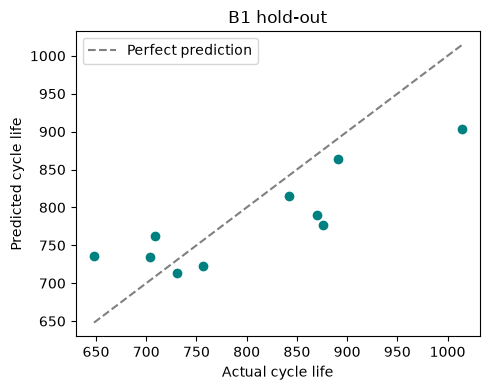

In [70]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(y_valid, valid_pred, color="teal")
limits = [min(y_valid.min(), valid_pred.min()), max(y_valid.max(), valid_pred.max())]
ax.plot(limits, limits, "--", color="gray", label="Perfect prediction")
ax.set(xlabel="Actual cycle life", ylabel="Predicted cycle life", title="B1 hold-out")
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "holdout_actual_vs_predicted.png", dpi=150)
plt.show()

## 9. Batch 1 전체로 재학습한 뒤 Batch 2 평가

설정 선택이 끝났으므로 같은 `best_alpha`를 사용하여 Batch 1의 46셀로 최종 모델을 학습합니다.
hold-out의 수명도 최종 학습에는 포함됩니다. 최종 중앙값·평균·표준편차는 **Batch 1 전체**에서 새로 계산합니다.
Batch 2에는 이 기준으로 `transform`만 적용합니다.

In [71]:
X_full = batch1[FEATURES].copy()
y_full = batch1[TARGET].copy()
final_imputer = SimpleImputer(strategy="median").set_output(transform="pandas")
X_full_imputed = final_imputer.fit_transform(X_full)
display(pd.Series(final_imputer.statistics_, index=FEATURES, name="Full B1 median"))

log10_delta_q_var    -3.85116
SOC_switch_pct       50.00000
Name: Full B1 median, dtype: float64

In [72]:
final_scaler = StandardScaler().set_output(transform="pandas")
X_full_scaled = final_scaler.fit_transform(X_full_imputed)
display(pd.DataFrame({"mean": final_scaler.mean_, "scale": final_scaler.scale_}, index=FEATURES))

,mean,scale
log10_delta_q_var,-3.923430,0.374138
SOC_switch_pct,51.521739,19.248647


In [73]:
final_ridge = Ridge(alpha=best_alpha)
final_ridge.fit(X_full_scaled, y_full)
print("최종 모델 학습 셀:", len(y_full), "/ 피처:", final_ridge.n_features_in_, "/ alpha:", best_alpha)

최종 모델 학습 셀: 46 / 피처: 2 / alpha: 0.01


In [74]:
X_test = batch2[FEATURES].copy()
y_test = batch2[TARGET].copy()
X_test_imputed = final_imputer.transform(X_test)
X_test_scaled = final_scaler.transform(X_test_imputed)
test_pred = final_ridge.predict(X_test_scaled)
test_metrics = calculate_metrics(y_test, test_pred)
test_predictions = batch2[["cell_uid", "policy_group", TARGET] + FEATURES].copy()
test_predictions["predicted"] = test_pred
test_predictions["error_cycles"] = test_pred - y_test
test_predictions["APE_percent"] = (test_pred - y_test).abs() / y_test * 100
worst_test_errors = test_predictions.sort_values("APE_percent", ascending=False).head(10)
display(pd.DataFrame([test_metrics], index=["B2 external evaluation"]))
display(worst_test_errors)

,MAPE_percent,MAE_cycles,RMSE_cycles,R2
B2 external evaluation,30.725164,150.963234,166.53248,0.42352


,cell_uid,policy_group,cycle_life,log10_delta_q_var,SOC_switch_pct,predicted,error_cycles,APE_percent
6,B2_6,C1=3.6|SOC=9|C2=5|suffix=none,393.0,-3.530040,9.0,700.431218,307.431218,78.226773
15,B2_15,C1=3.6|SOC=9|C2=5|suffix=none,396.0,-3.516252,9.0,694.293981,298.293981,75.326763
18,B2_18,C1=5.2|SOC=50|C2=4.25|suffix=none,449.0,-3.707303,50.0,749.617163,300.617163,66.952597
2,B2_2,C1=5.2|SOC=50|C2=4.25|suffix=none,424.0,-3.460248,50.0,639.647802,215.647802,50.860331
27,B2_29,C1=5.2|SOC=58|C2=4|suffix=none,452.0,-3.508248,58.0,655.214993,203.214993,44.959069
11,B2_11,C1=5.2|SOC=50|C2=4.25|suffix=none,449.0,-3.485393,50.0,650.840333,201.840333,44.953304
29,B2_31,C1=5.6|SOC=26|C2=4.5|suffix=none,425.0,-3.352359,26.0,609.019545,184.019545,43.298717
17,B2_17,C1=5.6|SOC=26|C2=4.5|suffix=none,471.0,-3.500344,26.0,674.891072,203.891072,43.288975
19,B2_19,C1=6|SOC=60|C2=3|suffix=none,392.0,-3.291958,60.0,557.489809,165.489809,42.216788
21,B2_21,C1=6|SOC=60|C2=3|suffix=none,408.0,-3.326679,60.0,572.944925,164.944925,40.427678


### Batch 2 오차 확인

왼쪽은 실제 수명과 예측 수명, 오른쪽은 실제 수명에 따른 오차입니다.
오차가 양수이면 수명을 길게 예측했고, 음수이면 짧게 예측했습니다.
이 결과는 한계를 설명하는 데 사용하고 alpha를 다시 선택하는 데 사용하지 않습니다.

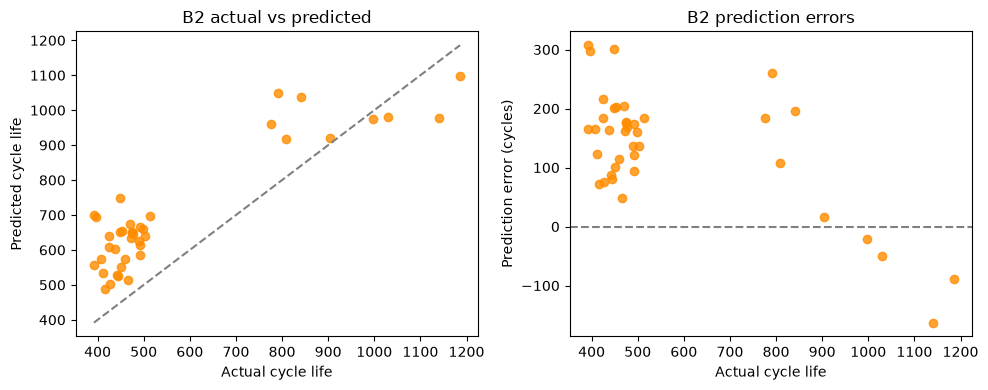

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(y_test, test_pred, color="darkorange", alpha=0.8)
limits = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
axes[0].plot(limits, limits, "--", color="gray")
axes[0].set(xlabel="Actual cycle life", ylabel="Predicted cycle life", title="B2 actual vs predicted")
axes[1].scatter(y_test, test_pred - y_test, color="darkorange", alpha=0.8)
axes[1].axhline(0, linestyle="--", color="gray")
axes[1].set(xlabel="Actual cycle life", ylabel="Prediction error (cycles)", title="B2 prediction errors")
fig.tight_layout()
fig.savefig(OUT / "test_predictions_and_errors.png", dpi=150)
plt.show()

## 10. 과제 성능표와 GAP

`Train`은 개발 36셀의 **nested CV 검증 폴드 MAPE 평균**, `Valid`는 10셀 hold-out,
`Test`는 Batch 1 전체로 재학습한 모델의 Batch 2 평가입니다.

MAPE는 작을수록 좋습니다. GAP은 **뒤 단계 MAPE − 앞 단계 MAPE**이며 단위는 `%p`입니다.
`Target−Test GAP`은 `Test MAPE − 9.1`로 계산하므로 양수는 목표보다 큰 오차를 뜻합니다.

In [76]:
valid_mape = float(valid_metrics["MAPE_percent"])
test_mape = float(test_metrics["MAPE_percent"])
model_performance = pd.DataFrame([{
    "model": "Ridge", "features": " + ".join(FEATURES), "target_transform": "identity",
    "alpha": best_alpha, "CV_MAPE_percent": cv_mape_mean, "CV_MAPE_std_pp": cv_mape_std,
    "Valid_MAPE_percent": valid_mape, "Test_MAPE_percent": test_mape,
    "Target_MAPE_percent": PAPER_TARGET_MAPE,
    "Train_Valid_GAP_pp": valid_mape - cv_mape_mean,
    "Valid_Test_GAP_pp": test_mape - valid_mape,
    "Target_Test_GAP_pp": test_mape - PAPER_TARGET_MAPE,
}])
day2_performance = pd.DataFrame([
    {"item": "Train (Batch 1 CV)", "value": cv_mape_mean, "unit": "%", "cells": len(X_train)},
    {"item": "Valid (Batch 1 hold-out)", "value": valid_mape, "unit": "%", "cells": len(X_valid)},
    {"item": "Test (Batch 2)", "value": test_mape, "unit": "%", "cells": len(X_test)},
    {"item": "GAP (Train-Valid)", "value": valid_mape - cv_mape_mean, "unit": "%p", "cells": np.nan},
    {"item": "GAP (Valid-Test)", "value": test_mape - valid_mape, "unit": "%p", "cells": np.nan},
    {"item": "GAP (Target-Test)", "value": test_mape - PAPER_TARGET_MAPE, "unit": "%p", "cells": np.nan},
])
display(day2_performance.round(3), model_performance.round(3))

,item,value,unit,cells
0,Train (Batch 1 CV),9.781,%,36.0
1,Valid (Batch 1 hold-out),7.007,%,10.0
2,Test (Batch 2),30.725,%,39.0
3,GAP (Train-Valid),-2.773,%p,NaN
4,GAP (Valid-Test),23.718,%p,NaN
5,GAP (Target-Test),21.625,%p,NaN


,model,features,target_transform,alpha,CV_MAPE_percent,CV_MAPE_std_pp,Valid_MAPE_percent,Test_MAPE_percent,Target_MAPE_percent,Train_Valid_GAP_pp,Valid_Test_GAP_pp,Target_Test_GAP_pp
0,Ridge,log10_delta_q_var + SOC_switch_pct,identity,0.01,9.781,2.351,7.007,30.725,9.1,-2.773,23.718,21.625


## 11. 최종 계수 읽기와 셀 하나 예측하기

`standardized_coefficient`는 다른 입력을 고정했을 때 해당 입력이 학습 표준편차 1만큼 증가하는 경우의
예측 수명 변화입니다. `original_unit_coefficient`는 원래 피처 단위 기준입니다.
계수는 이 데이터에 맞춘 관계이므로 인과 효과를 뜻하지 않습니다.

In [77]:
coefficient_table = pd.DataFrame({
    "feature": FEATURES,
    "standardized_coefficient": final_ridge.coef_,
    "original_unit_coefficient": final_ridge.coef_ / final_scaler.scale_,
    "B1_median": final_imputer.statistics_,
    "B1_mean": final_scaler.mean_,
    "B1_scale": final_scaler.scale_,
})
original_intercept = float(final_ridge.intercept_ - np.sum(
    final_ridge.coef_ * final_scaler.mean_ / final_scaler.scale_))
display(coefficient_table)
print(f"표준화 입력 기준 절편: {final_ridge.intercept_:.3f}")
print(f"원래 단위 입력 기준 절편: {original_intercept:.3f}")

,feature,standardized_coefficient,original_unit_coefficient,B1_median,B1_mean,B1_scale
0,log10_delta_q_var,-166.537282,-445.122102,-3.85116,-3.923430,0.374138
1,SOC_switch_pct,-13.951868,-0.724823,50.00000,51.521739,19.248647


표준화 입력 기준 절편: 844.717
원래 단위 입력 기준 절편: -864.344


아래는 이미 평가를 마친 Batch 2의 첫 셀을 한 번 더 예측하여 계산 과정을 확인하는 예입니다.
`raw → imputed → standardized → 계수 곱 → 절편 추가`를 따라가 보세요.
새 셀을 예측할 때에도 같은 두 컬럼 이름과 순서를 사용하면 됩니다.

In [78]:
one_cell = X_test.iloc[[0]].copy()
one_imputed = final_imputer.transform(one_cell)
one_scaled = final_scaler.transform(one_imputed)
one_prediction = float(final_ridge.predict(one_scaled)[0])
trace = pd.DataFrame({
    "raw": one_cell.iloc[0], "imputed": one_imputed.iloc[0],
    "standardized": one_scaled.iloc[0], "coefficient": final_ridge.coef_,
    "contribution_cycles": one_scaled.iloc[0] * final_ridge.coef_,
})
display(trace)
print("셀:", batch2.iloc[0]["cell_uid"])
print(f"예측 수명: {one_prediction:.1f} cycles / 실제 수명: {y_test.iloc[0]:.1f} cycles")
assert np.isclose(trace["contribution_cycles"].sum() + final_ridge.intercept_, one_prediction)

,raw,imputed,standardized,coefficient,contribution_cycles
log10_delta_q_var,-3.487265,-3.487265,1.165787,-166.537282,-194.146971
SOC_switch_pct,58.000000,58.000000,0.336557,-13.951868,-4.695595


셀: B2_0
예측 수명: 645.9 cycles / 실제 수명: 477.0 cycles


## 12. 결과 저장

선택 과정, 분할된 셀 목록, 성능표, 예측값, 계수와 모델을 저장합니다.
마지막 Pipeline에는 **이미 학습한 최종 전처리와 Ridge 객체**를 넣습니다.
저장한 모델은 원래 두 피처를 입력받아 전처리와 예측까지 수행합니다.

In [79]:
split_membership = batch1[["cell_uid", "batch_id", "policy_group", TARGET]].copy()
split_membership["split"] = "B1 development"
split_membership.loc[valid_idx, "split"] = "B1 hold-out"
test_membership = batch2[["cell_uid", "batch_id", "policy_group", TARGET]].copy()
test_membership["split"] = "B2 external evaluation"
split_membership = pd.concat([split_membership, test_membership], ignore_index=True)

csv_outputs = {
    "features_by_cell.csv": data,
    "cohort_audit.csv": cohort_audit,
    "excluded_cells.csv": excluded_cells,
    "split_membership.csv": split_membership,
    "alpha_cv_trials.csv": alpha_trials,
    "alpha_cv_scores.csv": alpha_scores,
    "nested_inner_trials.csv": nested_trials,
    "nested_cv_fold_scores.csv": nested_fold_scores,
    "cv_oof_predictions.csv": cv_oof_predictions,
    "holdout_predictions.csv": holdout_predictions,
    "test_predictions.csv": test_predictions,
    "worst_test_errors.csv": worst_test_errors,
    "model_performance.csv": model_performance,
    "day2_performance.csv": day2_performance,
    "coefficients.csv": coefficient_table,
    "holdout_metrics.csv": pd.DataFrame([valid_metrics]),
    "test_metrics.csv": pd.DataFrame([test_metrics]),
}
for filename, frame in csv_outputs.items():
    frame.to_csv(OUT / filename, index=False, encoding="utf-8-sig")
print("저장한 CSV:", len(csv_outputs))

저장한 CSV: 17


In [80]:
final_pipeline = Pipeline([
    ("imputer", final_imputer), ("scaler", final_scaler), ("ridge", final_ridge)
])
assert list(final_pipeline.feature_names_in_) == FEATURES
assert final_pipeline.named_steps["ridge"].n_features_in_ == 2
assert np.allclose(final_pipeline.predict(X_test), test_pred)
joblib.dump(final_pipeline, OUT / "ridge_2features.joblib")

config = {
    "features": FEATURES, "target": TARGET, "target_transform": "identity",
    "model": "Ridge", "selected_alpha": best_alpha, "alpha_candidates": ALPHAS,
    "seed": SEED, "holdout_group_fraction": 0.2,
    "alpha_selection_folds": 3, "reporting_outer_folds": 5, "reporting_inner_folds": 3,
    "B1_development_cells": len(X_train), "B1_holdout_cells": len(X_valid),
    "final_fit_B1_cells": len(X_full), "B2_evaluation_cells": len(X_test),
    "B3_used_for_training_or_evaluation": False,
    "policy_group_definition": "C1 + SOC + C2 + normalized suffix; fallback normalized policy text",
    "policy_metadata_used_as_predictor": False,
    "paper_target_mape_percent": PAPER_TARGET_MAPE,
    "official_cell_merge_applied": False, "holdout_and_B2_previously_viewed_in_EDA": True,
    "cohort_note": "Raw local cohort; B2 is 2018-02-20, so 9.1% is a reference target.",
    "source_sha256": {
        name: hashlib.sha256((SOURCE / name).read_bytes()).hexdigest()
        for name in ["cell_metadata.csv", "delta_q_features.csv", "current_features.csv"]
    },
    "report_url": "https://app.notion.com/p/3ecd54b5a6d7818f99bde98f1cef9db1",
}
(OUT / "model_config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
print("모델과 설정 저장 완료:", OUT)

모델과 설정 저장 완료: /Users/suyeong/Downloads/archive/Modeling/results/ridge_step_by_step


## 결과 해석과 직접 해볼 실습

이번 입력은 로컬 원본 수명을 사용한 EDA 결과이며 공식 셀 병합·수명 보정을 적용하지 않았습니다.
로컬 Batch 2는 2018-02-20 데이터로 논문의 Batch 2 코호트와 다릅니다.
hold-out과 Batch 2의 데이터도 이전 EDA에서 확인했으므로 완전히 처음 보는 데이터라고 해석하지 않습니다.
**9.1%는 과제의 참고 목표**로 비교하고, 최종 성능과 코호트 차이를 함께 기록하세요.

1. 연습 모델의 `alpha=1.0`만 바꿔 계수 크기와 Train-fit MAPE가 어떻게 달라지는지 확인하세요.
2. `alpha_cv_scores`에서 평균과 표준편차를 함께 읽고 선택한 `alpha`의 근거를 설명하세요.
3. `worst_test_errors`에서 짧은 수명 셀의 오차와 두 피처 값을 확인하세요.

최종 결과를 재현할 때는 원래 설정으로 **Restart Kernel → Run All**을 실행합니다.
Batch 2 점수로 설정을 다시 고르면 같은 Batch 2 결과는 모델 선택 이후의 재평가가 됩니다.